**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Juan Manuel Cuevas Gaytan
*   MATRÍCULA: A01197813


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [1]:
# Importa las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe? 
	- **R= El dataset no cuenta con valores nulos o faltantes**





In [2]:
# Cargar dataset
weather_df = pd.read_csv('./data/cleaned_weather.csv')

In [3]:
# Dimensionalidad del dataframe e identificadores de las columnas
print("Dimensionalidad:", weather_df.shape)
print("Columnas:", weather_df.columns)

Dimensionalidad: (52696, 21)
Columnas: Index(['date', 'p', 'T', 'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh',
       'H2OC', 'rho', 'wv', 'max. wv', 'wd', 'rain', 'raining', 'SWDR', 'PAR',
       'max. PAR', 'Tlog'],
      dtype='str')


In [4]:
# Renombrar columnas
cols = [
	'date', 'p', 'T',
	'Tpot', 'rh', 'VPact',
	'sh', 'H2OC', 'rho',
	'wv', 'wd', 'rain',
	'raining'
]
names = [
	'medicion', 'presion_atmosferica', 'temperatura_celsius',
	'temperatura_kelvin', 'humedad_relativa', 'presion_vapor',
	'humedad_especifica', 'concentracion_vapor', 'densidad_aire',
	'velocidad_viento', 'direccion_viento', 'precipitacion_total',
	'duracion_lluvia'
]

weather_df = weather_df[cols]
weather_df.columns = names

In [5]:
# Imprimir las primeros 5 registros
weather_df.head(5)

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,2020-01-01 00:10:00,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0.0
1,2020-01-01 00:20:00,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0.0
2,2020-01-01 00:30:00,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0.0
3,2020-01-01 00:40:00,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0.0
4,2020-01-01 00:50:00,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0.0


In [6]:
# Imprimer los ultimos 5 registros
weather_df.tail(5)

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,2020-12-31 23:20:00,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0.0
52692,2020-12-31 23:30:00,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0.0
52693,2020-12-31 23:40:00,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0.0
52694,2020-12-31 23:50:00,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0.0
52695,2021-01-01 00:00:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0.0


In [7]:
weather_df.isna().sum()

medicion               0
presion_atmosferica    0
temperatura_celsius    0
temperatura_kelvin     0
humedad_relativa       0
presion_vapor          0
humedad_especifica     0
concentracion_vapor    0
densidad_aire          0
velocidad_viento       0
direccion_viento       0
precipitacion_total    0
duracion_lluvia        0
dtype: int64

2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [8]:
# Ver los tipos de datos de la columns
weather_df.dtypes

medicion                   str
presion_atmosferica    float64
temperatura_celsius    float64
temperatura_kelvin     float64
humedad_relativa       float64
presion_vapor          float64
humedad_especifica     float64
concentracion_vapor    float64
densidad_aire          float64
velocidad_viento       float64
direccion_viento       float64
precipitacion_total    float64
duracion_lluvia        float64
dtype: object

In [9]:
# Verificar individualement el tipo de dato de medicion
print(type(weather_df['medicion'][0]))
print(weather_df['medicion'].dtype)

<class 'str'>
str


In [10]:
weather_df['medicion'] = pd.to_datetime(
	weather_df['medicion'], 
	format='%Y-%m-%d %H:%M:%S').dt.strftime("%d/%m/%y %H:%M")

# Verificar que las fechas se convirtieron 
print(weather_df['medicion'].sort_values(ascending=False).head(1))


52694    31/12/20 23:50
Name: medicion, dtype: str


In [11]:
weather_df['hora'] = weather_df['medicion'].str.split(' ').str[1]
weather_df['fecha'] = weather_df['medicion'].str.split(' ').str[0]

print(weather_df[['medicion', 'fecha', 'hora']].sort_values('medicion',ascending=False).head(1))

             medicion     fecha   hora
52694  31/12/20 23:50  31/12/20  23:50


3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [12]:
# Determinar la cantidad de valores unicos
weather_df.nunique()

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
hora                     144
fecha                    367
dtype: int64

In [13]:
weather_df['medicion'].value_counts().sort_values(ascending=False).head(1)

medicion
12/05/20 06:00    2
Name: count, dtype: int64

In [14]:
weather_df[weather_df['medicion'].duplicated(keep=False)]

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,hora,fecha
19043,12/05/20 06:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0.0,06:00,12/05/20
19044,12/05/20 06:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0.0,06:00,12/05/20


In [15]:
print('Antes: ', weather_df.shape)
weather_df = weather_df.drop_duplicates(keep='first').reset_index(drop=True)
print('Despues: ', weather_df.shape)

Antes:  (52696, 15)
Despues:  (52695, 15)


4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
	-	**Son 144 horas diferentes porque al dia se realizaban mediciones cada 10 minutos durante el dia lo que equivale a 144 mediciones en un lapso de 24 horas**
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
	- **Si no estaba garantizado hay tres fechas que no cuentan con dataos completas, dos de ellas son por que son el primer y ultimo registro historico de la mediciones a 01/01/20 cuenta solo 143 ya que no cuenta con la medicion en el punto 00:00:00 ya que marca el comienzo de las medicions y en 01/01/21 es la ultima medicion a las 00:00:00, pero la fecha 29/05/20 le hacen falta 9 mediciones.**
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [16]:
# Verificar cantidad de horas unicas
print(weather_df['hora'].nunique())

144


In [17]:
conteo = weather_df.groupby('fecha').size()
conteo.reset_index(name='conteo')
conteo[conteo != 144]

fecha
01/01/20    143
01/01/21      1
29/05/20    135
dtype: int64

In [18]:
weather_df = weather_df[weather_df['fecha'].str.split('/').str[2] == '20']
weather_df['fecha'].str.split('/').str[2].value_counts()

# Solo fue eliminado el registro que pertenece al final
# historico de los datos en el 2021

fecha
20    52694
Name: count, dtype: int64

In [19]:
# Eliminar columna de 'medicion'
weather_df.drop(columns=['medicion'], inplace=True)
weather_df.columns

Index(['presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin',
       'humedad_relativa', 'presion_vapor', 'humedad_especifica',
       'concentracion_vapor', 'densidad_aire', 'velocidad_viento',
       'direccion_viento', 'precipitacion_total', 'duracion_lluvia', 'hora',
       'fecha'],
      dtype='str')

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
	- **La precipitacion maxima fue de 11.2 registrada el 16/06/20.**
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
	- **Los tres dias que regristraron las velocidades de viento mas altas fueron 10/02/20, 16/02/20 y 09/02/20.**
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?
	- **Solo 5 dias.**

In [20]:
# Agrupar por dia
indicadores_diarios = weather_df.groupby('fecha').max()
indicadores_diarios.reset_index(inplace=True)

In [21]:
# Seleccionar la fecha con la mayor precipitacion total
indicadores_diarios[indicadores_diarios['precipitacion_total'] == indicadores_diarios['precipitacion_total'].max()][['fecha', 'precipitacion_total']]

,fecha,precipitacion_total
185,16/06/20,11.2


In [22]:
# Seleccionar los tres dias con las velocidades de viento mas altas
indicadores_diarios.sort_values('velocidad_viento', ascending=False).head(3)[['fecha', 'velocidad_viento']]

,fecha,velocidad_viento
109,10/02/20,13.77
181,16/02/20,13.00
97,09/02/20,12.52


In [23]:
# Cantidad de diasque rebasaron el 90% de humedad y 30 grados celsius
indicadores_diarios[(indicadores_diarios['temperatura_celsius'] > 30) & (indicadores_diarios['humedad_relativa'] > 90.0)].shape[0]

5

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
	- **La concentracion de vapor tiene una desviacion estandar de 4.573, lo que indica que hay una disprecion considerable entre sus valores con respecto a la media, por lo acertar el valor de la concentracion del valor en un dia seria complicado devido a la alta desviacion.**
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
	- **La mediana de la presion atmosferica es 993.3, y lo que significa es que es el punto medio de los valores registrados para la presion atmosferica durante el todo el periodo, durante el resto del tiempo el una mitad del tiempo tuvo valores menores o iguales 993.3 y la otra mitad tuvo valores iguales o mayores.**
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?
	- **El tercer cuartil obtuvo un valor de 600.0, el cual tambien fue el valor maximo de duracion de lluvia en todo el dataset, esto indica que el 25% de los dias que obtuvieron los valores mas altos en duracion de lluvia registaron el valor maximo de 600.0.**

In [24]:
# Describir indicadores_diarios
indicadores_diarios.describe()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000


In [25]:
# Desviacion estandar de la concentracion de vapor
print(indicadores_diarios['concentracion_vapor'].std())

4.573267035838974


In [26]:
# Mediana de la presion atmosferica
print(indicadores_diarios['presion_atmosferica'].median())

993.3


In [27]:
# Tercer cuartil de la duracion de la lluvia
print('Q3: ', indicadores_diarios['duracion_lluvia'].quantile(0.75))
# Valor maximo de duraion de lluvia
print('Valor maximo de duracion de lluvia: ',
    indicadores_diarios['duracion_lluvia'].max())

Q3:  600.0
Valor maximo de duracion de lluvia:  600.0


7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

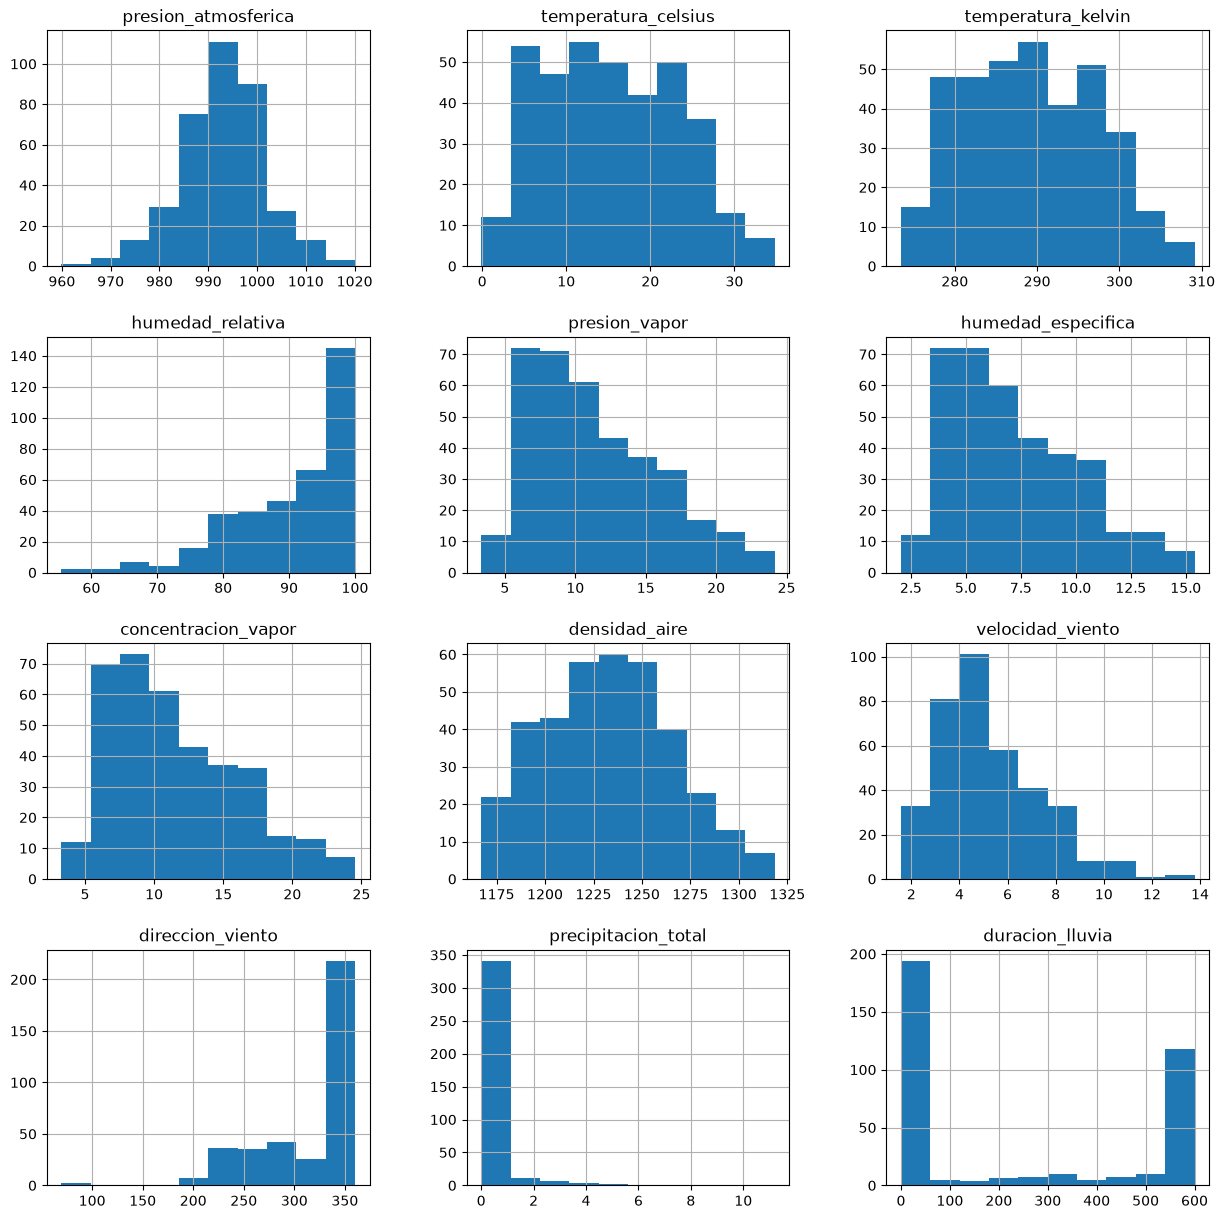

In [28]:
indicadores_diarios.hist(figsize=(15,15))
plt.show()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [29]:
indicadores_diarios['mes'] = indicadores_diarios['fecha'].str.split('/').str[1]
print(indicadores_diarios['mes'].value_counts())

mes
01    31
03    31
05    31
07    31
08    31
10    31
12    31
04    30
06    30
09    30
11    30
02    29
Name: count, dtype: int64


In [30]:
indicadores_mensuales = indicadores_diarios.groupby('mes')[['humedad_relativa', 'temperatura_celsius', 'velocidad_viento']].mean()
indicadores_mensuales.reset_index(inplace=True)
indicadores_mensuales.head()

,mes,humedad_relativa,temperatura_celsius,velocidad_viento
0,01,89.776129,6.821290,5.031935
1,02,85.719655,8.962414,7.489655
2,03,85.372903,9.683871,6.421290
3,04,80.938667,16.879667,4.997000
4,05,87.464839,17.135484,4.865806


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [31]:
indicadores_mensuales = pd.pivot_table(indicadores_diarios, index='mes', values=['humedad_relativa', 'temperatura_celsius', 'velocidad_viento'], aggfunc='mean')
indicadores_mensuales.reset_index(inplace=True)
indicadores_mensuales['indice_calor'] = indicadores_mensuales['temperatura_celsius'] + 0.33 * indicadores_mensuales['humedad_relativa'] - 0.7 * indicadores_mensuales['velocidad_viento'] - 4
indicadores_mensuales.sort_values('mes', ascending=True).head()

,mes,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
0,01,89.776129,6.821290,5.031935,28.925058
1,02,85.719655,8.962414,7.489655,28.007141
2,03,85.372903,9.683871,6.421290,29.362026
3,04,80.938667,16.879667,4.997000,36.091527
4,05,87.464839,17.135484,4.865806,38.592816


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.
	- **La funcion melt lo que hace es convertir el dataset en un formato largo unificando identificador, atributos y valores en tres columnas y continua siendo un Dataframe, y la funcion stack produce una estructura de tipo Serie agrupa los atributos por identificadores, por lo que al mostrar un identificador muestra sus atributos y no continua listando todos los identificador con un solo atributo.**

In [32]:
formato_alto = indicadores_mensuales.melt(id_vars='mes', value_vars=['humedad_relativa', 'temperatura_celsius', 'velocidad_viento', 'indice_calor'], var_name='indicador', value_name='valor')
formato_alto.head()

,mes,indicador,valor
0,01,humedad_relativa,89.776129
1,02,humedad_relativa,85.719655
2,03,humedad_relativa,85.372903
3,04,humedad_relativa,80.938667
4,05,humedad_relativa,87.464839


In [33]:
stacked_df = indicadores_mensuales.set_index('mes').stack()
stacked_df.head(4)

mes                     
01   humedad_relativa       89.776129
     temperatura_celsius     6.821290
     velocidad_viento        5.031935
     indice_calor           28.925058
dtype: float64

In [34]:
print(type(stacked_df))
print(type(formato_alto))

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


In [35]:
stacked_df.unstack().head()

,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
mes,,,,
01,89.776129,6.821290,5.031935,28.925058
02,85.719655,8.962414,7.489655,28.007141
03,85.372903,9.683871,6.421290,29.362026
04,80.938667,16.879667,4.997000,36.091527
05,87.464839,17.135484,4.865806,38.592816


In [36]:
formato_ancho = formato_alto.pivot(index='mes', columns='indicador', values='valor')
formato_ancho.head()

indicador,humedad_relativa,indice_calor,temperatura_celsius,velocidad_viento
mes,,,,
01,89.776129,28.925058,6.821290,5.031935
02,85.719655,28.007141,8.962414,7.489655
03,85.372903,29.362026,9.683871,6.421290
04,80.938667,36.091527,16.879667,4.997000
05,87.464839,38.592816,17.135484,4.865806


---

**Referencias**

* Anthropic. (2026). Claude (Sonnet 5) [Modelo de lenguaje grande]. Utilizado para depuración de código, identificación de errores y verificación de resultados. https://claude.ai/

* Jafari, R. (2022). Hands-On Data Preprocessing in Python. Packt Publishing. 

* McKinney, W. (2022). Python for Data Analysis (3rd ed.). O'Reilly Media. 

* Pandas. (2026). Pandas Documentation[Documentación de software]. https://pandas.pydata.org/docs/index.html
---